# Research Question 3: 
### How does the average number of charting weeks in Canada differ between songs with danceability and speechiness levels above and below 0.5?


In [53]:
import pandas as pd
import oracledb
import matplotlib.pyplot as plt

#### 1. Oracle DB Connection and SQL File Insertion

In [ ]:
# connecting to oracle database 

dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(
    user="ora_emmaoh",
    password="a18182394",
    dsn=dsn
)

cur = connection.cursor()
# read the SQL file
with open("insert_data_v3.sql", "r", encoding="utf-8") as file:
    sql_script = file.read()

# split SQL statements
statements = sql_script.split(";")

# execute each statement and throw error if there is a sql statement error
for i, stmt in enumerate(statements, start=1):
    stmt = stmt.strip()
    if stmt:
        try:
            cur.execute(stmt)
        except Exception as e:
            print(f"Skipping error at statement {i}: {e} at {stmt}")

connection.commit()

#### 2a. Danceability Query

In [38]:
# Query SQL data and put into pandas dataframe 

# 1st audio level: danceability
rq3_danceability = """
SELECT category, AVG(weeks_on_chart) AS avg_weeks_on_chart
FROM (
  SELECT
    weeks_on_chart,
    CASE
      WHEN danceability > 0.5 THEN 'Danceability > 0.5'
      ELSE 'Danceability <= 0.5'
    END AS category
    FROM SPOTIFY_SONGS
    NATURAL JOIN BILLBOARD_WEEKS
)
GROUP BY category
"""

rq3_danceability_df = pd.read_sql(rq3_danceability, connection)
rq3_danceability_df.head()

/var/folders/cc/hz1f3chx7jlgxd798r_pz97w0000gn/T/ipykernel_1830/2864788826.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rq3_danceability_df = pd.read_sql(rq3_danceability, connection)


,CATEGORY,AVG_WEEKS_ON_CHART
0,Danceability <= 0.5,10.473684
1,Danceability > 0.5,12.762590


#### 2b. Speechiness Query

In [39]:
# 2nd audio level: speechiness
rq3_speechiness = """
SELECT category, AVG(weeks_on_chart) AS avg_weeks_on_chart
FROM (
  SELECT
    weeks_on_chart,
    CASE
      WHEN speechiness > 0.5 THEN 'Speechiness > 0.5'
      ELSE 'Speechiness <= 0.5'
    END AS category
    FROM SPOTIFY_SONGS
    NATURAL JOIN BILLBOARD_WEEKS
)
GROUP BY category
"""

rq3_speechiness_df = pd.read_sql(rq3_speechiness, connection)
rq3_speechiness_df.head()

/var/folders/cc/hz1f3chx7jlgxd798r_pz97w0000gn/T/ipykernel_1830/3008033920.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rq3_speechiness_df = pd.read_sql(rq3_speechiness, connection)


,CATEGORY,AVG_WEEKS_ON_CHART
0,Speechiness > 0.5,2.500000
1,Speechiness <= 0.5,12.754266


#### 3a. Danceability Visualization

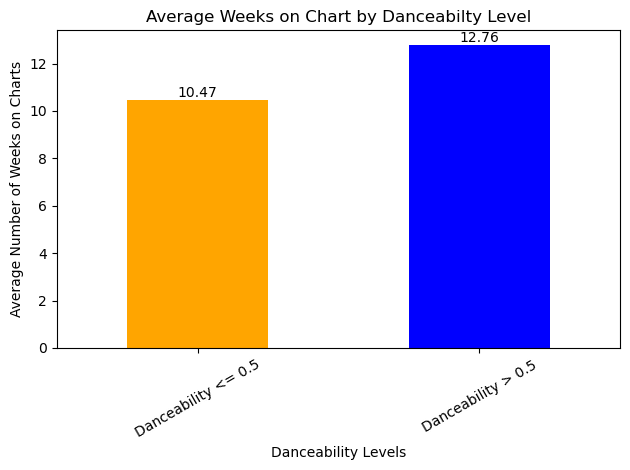

In [51]:
# visualizations 

# 1st: danceability 
rq3_1 = rq3_danceability_df.plot(
  x="CATEGORY",
  y="AVG_WEEKS_ON_CHART", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq3_1.containers:
    rq3_1.bar_label(container, fmt="%.2f")

plt.title("Average Weeks on Chart by Danceabilty Level")
plt.xticks(rotation=30)
plt.xlabel("Danceability Levels")
plt.ylabel("Average Number of Weeks on Charts")
plt.tight_layout()
plt.show()

#### 3b. Speechiness Visualization

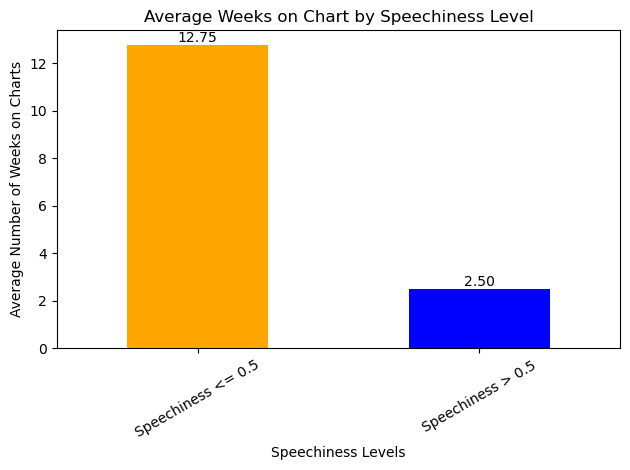

In [50]:
# 2nd: speechiness 
rq3_speechiness_df = rq3_speechiness_df.sort_values("CATEGORY")
rq3_2 = rq3_speechiness_df.plot(
  x="CATEGORY",
  y="AVG_WEEKS_ON_CHART", 
  kind="bar",
  color=["orange", "blue"],
  legend=False
)

for container in rq3_2.containers:
    rq3_2.bar_label(container, fmt="%.2f")

plt.title("Average Weeks on Chart by Speechiness Level")
plt.xticks(rotation=30)
plt.xlabel("Speechiness Levels")
plt.ylabel("Average Number of Weeks on Charts")
plt.tight_layout()
plt.show()

In [52]:
cur.close()
connection.close()